# Medical No Show Predication & Demand Forecasting

## Importing libraries

In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [226]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,recall_score, confusion_matrix,classification_report, roc_curve)
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [227]:
import joblib

In [228]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (mean_absolute_error,mean_absolute_percentage_error,r2_score)

## Understanding the data

In [229]:
df= pd.read_csv("Medical_appointment_data.csv")

In [230]:
df.head(5)

,specialty,appointment_time,gender,no_show,disability,place,appointment_shift,age,under_12_years_old,over_60_years_old,...,storm_day_before,rain_intensity,heat_intensity,appointment_date_continuous,Hipertension,Diabetes,Alcoholism,Handcap,Scholarship,SMS_received
0,psychotherapy,17,F,yes,intellectual,Lake Marvinville,afternoon,9.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
1,NaN,7,M,no,intellectual,ITAPEMA,morning,11.0,1,0,...,1,no_rain,cold,2020-01-01,0,0,0,0,0,0
2,speech therapy,16,M,no,intellectual,ITAJAÍ,afternoon,8.0,1,0,...,1,no_rain,warm,2020-01-01,0,0,0,0,0,0
3,speech therapy,14,M,yes,intellectual,Sarahside,afternoon,9.0,1,0,...,1,moderate,mild,2020-01-01,0,0,0,0,0,1
4,physiotherapy,8,M,no,motor,ITAJAÍ,morning,NaN,0,0,...,1,no_rain,mild,2020-01-01,0,0,0,0,0,0


In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   object 
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  object 
 3   no_show                      109593 non-null  object 
 4   disability                   92992 non-null   object 
 5   place                        98054 non-null   object 
 6   appointment_shift            109593 non-null  object 
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 13 

In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109593 entries, 0 to 109592
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   specialty                    89466 non-null   object 
 1   appointment_time             109593 non-null  int64  
 2   gender                       109593 non-null  object 
 3   no_show                      109593 non-null  object 
 4   disability                   92992 non-null   object 
 5   place                        98054 non-null   object 
 6   appointment_shift            109593 non-null  object 
 7   age                          86633 non-null   float64
 8   under_12_years_old           109593 non-null  int64  
 9   over_60_years_old            109593 non-null  int64  
 10  patient_needs_companion      109593 non-null  int64  
 11  average_temp_day             107382 non-null  float64
 12  average_rain_day             107348 non-null  float64
 13 

In [233]:
df.isnull().sum()

specialty                      20127
appointment_time                   0
gender                             0
no_show                            0
disability                     16601
place                          11539
appointment_shift                  0
age                            22960
under_12_years_old                 0
over_60_years_old                  0
patient_needs_companion            0
average_temp_day                2211
average_rain_day                2245
max_temp_day                    2227
max_rain_day                    2263
rainy_day_before                   0
storm_day_before                   0
rain_intensity                     0
heat_intensity                     0
appointment_date_continuous        0
Hipertension                       0
Diabetes                           0
Alcoholism                         0
Handcap                            0
Scholarship                        0
SMS_received                       0
dtype: int64

In [234]:
df.isnull().mean()*100

specialty                      18.365224
appointment_time                0.000000
gender                          0.000000
no_show                         0.000000
disability                     15.147865
place                          10.528957
appointment_shift               0.000000
age                            20.950243
under_12_years_old              0.000000
over_60_years_old               0.000000
patient_needs_companion         0.000000
average_temp_day                2.017465
average_rain_day                2.048488
max_temp_day                    2.032064
max_rain_day                    2.064913
rainy_day_before                0.000000
storm_day_before                0.000000
rain_intensity                  0.000000
heat_intensity                  0.000000
appointment_date_continuous     0.000000
Hipertension                    0.000000
Diabetes                        0.000000
Alcoholism                      0.000000
Handcap                         0.000000
Scholarship     

In [235]:
df["specialty"].unique()

array(['psychotherapy', nan, 'speech therapy', 'physiotherapy',
       'occupational therapy', 'assist', 'pedagogo', 'enf',
       'sem especialidade'], dtype=object)

In [236]:
df["disability"].unique()

array(['intellectual', 'motor', nan, ' '], dtype=object)

In [237]:
df["age"].value_counts()

age
8.0     8989
9.0     8553
18.0    8370
7.0     7358
19.0    6947
        ... 
86.0      19
84.0      19
85.0      16
88.0       7
89.0       1
Name: count, Length: 92, dtype: int64

In [238]:
df['specialty'].value_counts()

specialty
psychotherapy           28645
speech therapy          22322
physiotherapy           21004
occupational therapy    11319
pedagogo                 3536
enf                      1681
assist                    635
sem especialidade         324
Name: count, dtype: int64

In [239]:
df['disability'].value_counts()

disability
intellectual    62852
motor           29721
                  419
Name: count, dtype: int64

<Axes: xlabel='no_show', ylabel='count'>

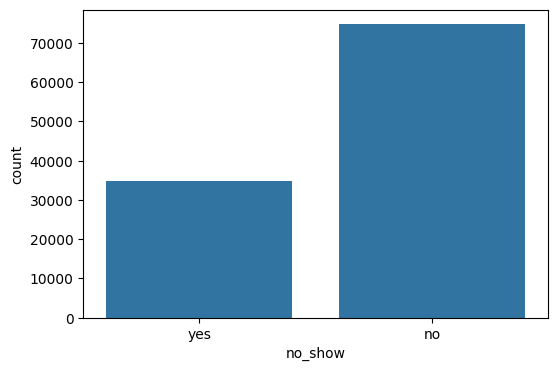

In [240]:
plt.figure(figsize=(6,4))
sns.countplot(x='no_show', data=df)

<Axes: xlabel='specialty', ylabel='count'>

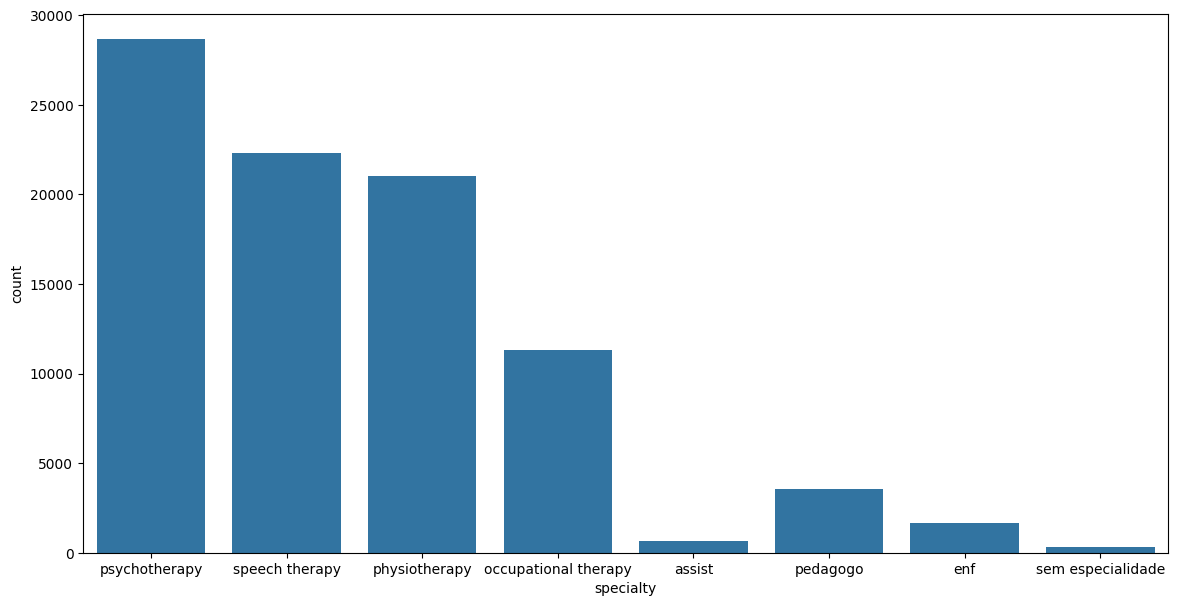

In [241]:
plt.figure(figsize=(14,7))
sns.countplot(x='specialty',data=df)

<Axes: xlabel='disability', ylabel='count'>

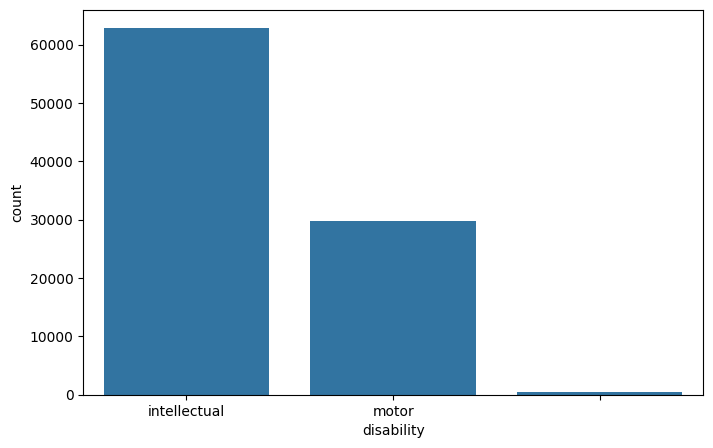

In [242]:
plt.figure(figsize=(8,5))
sns.countplot(x='disability',data=df)

<Axes: xlabel='age', ylabel='count'>

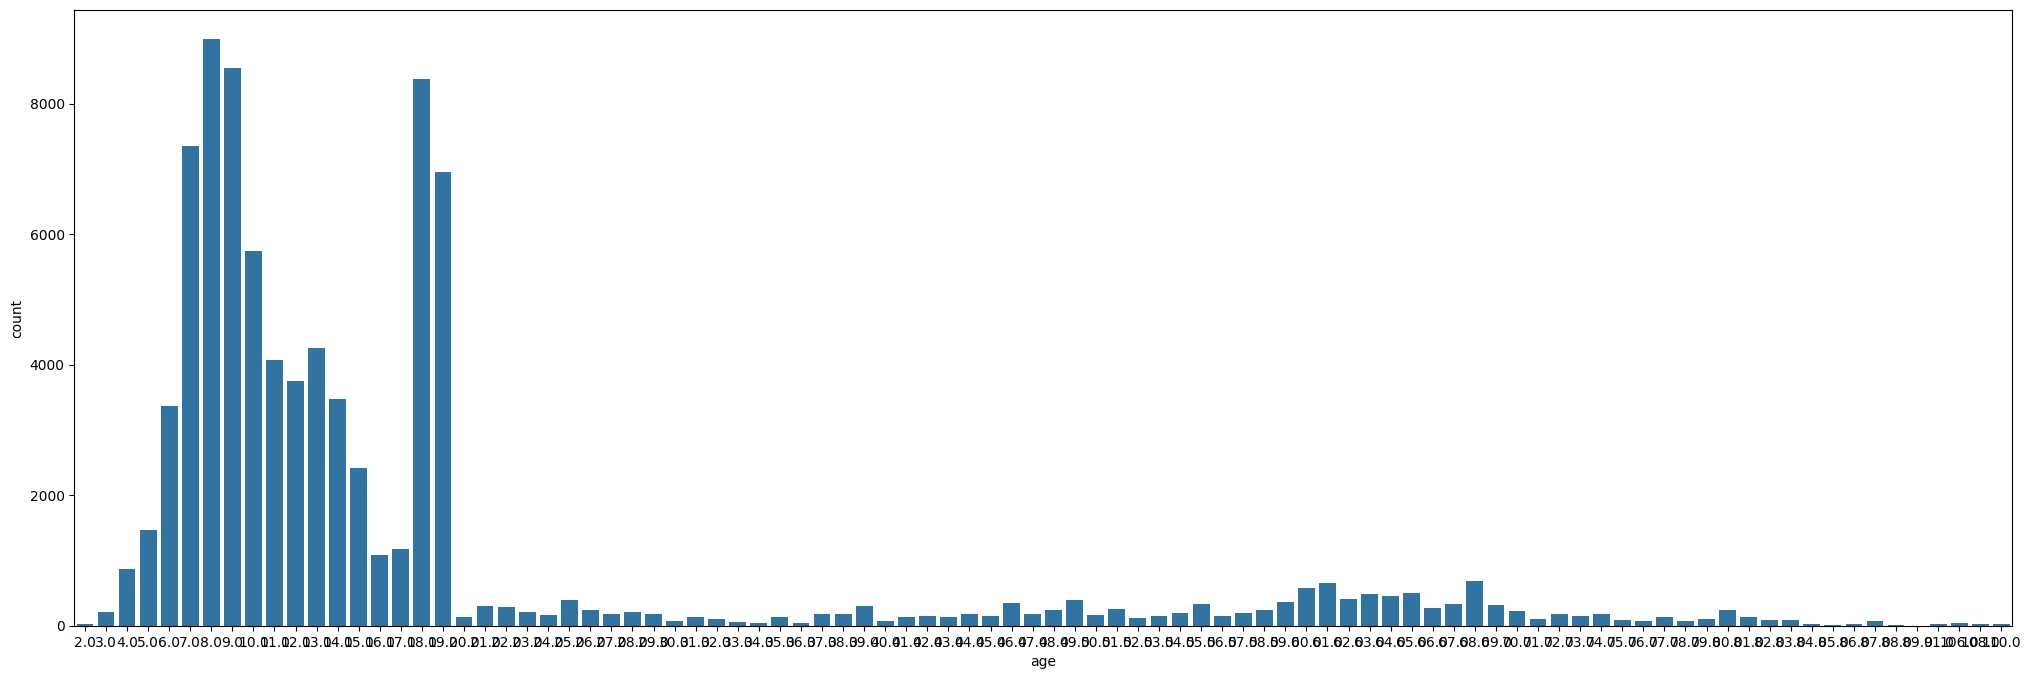

In [243]:
plt.figure(figsize=(25,8))
sns.countplot(x='age',data=df)

<Axes: xlabel='heat_intensity', ylabel='count'>

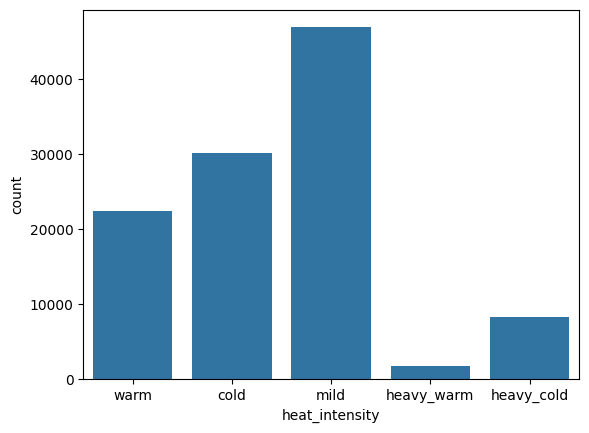

In [244]:
sns.countplot(x='heat_intensity',data=df)

<Axes: xlabel='rain_intensity', ylabel='count'>

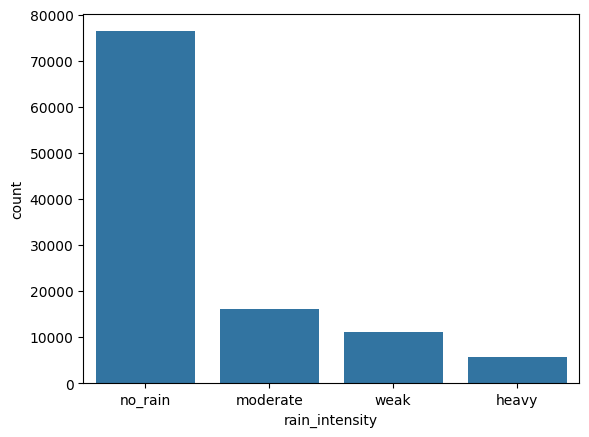

In [245]:
sns.countplot(x='rain_intensity',data=df)

<Axes: xlabel='appointment_shift', ylabel='count'>

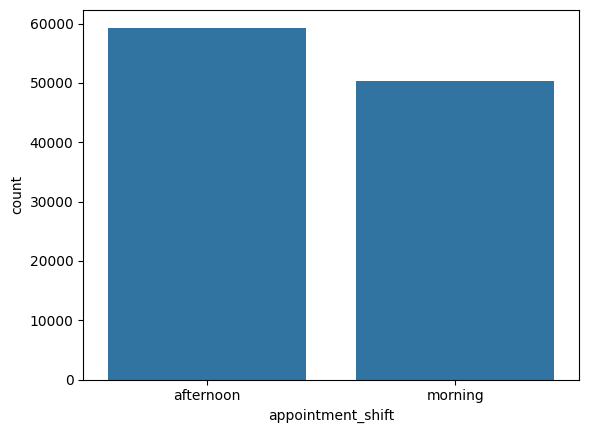

In [246]:
sns.countplot(x='appointment_shift',data=df)

<Axes: xlabel='gender', ylabel='count'>

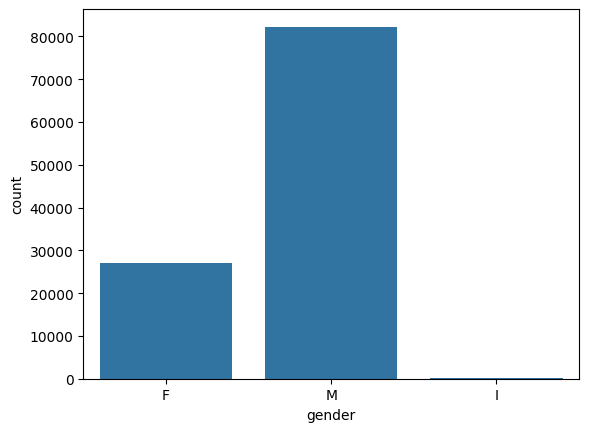

In [247]:
sns.countplot(x='gender',data=df)

## Data Cleaning

### Filling empty elements

In [248]:
df["age"] = df["age"].fillna(df["age"].median())

In [249]:
df["specialty"] = df["specialty"].fillna("Unknown")

In [250]:
df["place"] = df["place"].fillna("Unknown")

In [251]:
df["disability"] = df["disability"].fillna("None")

In [252]:
df["average_temp_day"] = df["average_temp_day"].ffill()
df["average_rain_day"] = df["average_rain_day"].ffill()
df["max_temp_day"] = df["max_temp_day"].ffill()
df["max_rain_day"] = df["max_rain_day"].ffill()

### Making the data uniform

In [255]:
print(df.duplicated().sum())

16


In [256]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [257]:
df["appointment_date_continuous"] = pd.to_datetime(df["appointment_date_continuous"])

In [258]:
df["age"] = df["age"].astype(int)

In [259]:
df["disability"] = df["disability"].str.strip().str.title()

In [260]:
df["specialty"] = df["specialty"].str.strip().str.title()

In [261]:
df["place"] = df["place"].str.strip().str.title()

In [262]:
df["appointment_shift"] = df["appointment_shift"].str.strip().str.title()

In [263]:
df.shape

(109577, 26)

### Feature Enginering

In [266]:
df["appointment_date_continuous"] = pd.to_datetime(df["appointment_date_continuous"])

In [267]:
df["day"] = df["appointment_date_continuous"].dt.day_name()

In [268]:
df["month"] = df["appointment_date_continuous"].dt.month

In [269]:
df["weekend"] = df["appointment_date_continuous"].dt.dayofweek.isin([5, 6]).astype(int)

In [270]:
df["appointment_time"].value_counts()

appointment_time
13    15772
9     13804
14    13205
10    11886
8     11499
17    10008
15     9302
16     8727
7      7865
11     4964
18     2281
12      264
Name: count, dtype: int64

In [271]:
print(
    df[df['no_show'] == 'yes']
    .groupby('appointment_time')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='no_shows')
)

    appointment_time  no_shows
0                 13      4839
1                 10      4637
2                  9      4425
3                 14      4042
4                  8      3761
5                 17      3716
6                 16      2875
7                  7      2486
8                 15      2440
9                 11      1240
10                18       323
11                12        48


In [272]:
print(df['age'].value_counts().sort_index().reset_index())

    age  count
0     2     31
1     3    214
2     4    866
3     5   1473
4     6   3367
..  ...    ...
87   89      1
88   91     34
89  106     44
90  108     20
91  110     20

[92 rows x 2 columns]


In [273]:
df["age_group"]=pd.cut(
    df["age"],
    bins=[0,3,12,20,40,60,80,120],
    labels=["Baby","Kids","Teens","Young Adults","Adults","Seniors","Elderly"]
)

In [274]:
df["age_group"].value_counts()

age_group
Kids            67121
Teens           27874
Seniors          5669
Adults           4633
Young Adults     3483
Elderly           552
Baby              245
Name: count, dtype: int64

In [275]:
health= ["Hipertension", "Diabetes", "Alcoholism", "Handcap"]
df["health_issues_count"] = df[health].sum(axis=1)

In [276]:
df["health_issues"] = (df["health_issues_count"] > 0).astype(int)

In [277]:
df["patient"] = (df["health_issues_count"] >= 2).astype(int)

In [278]:
df["extreme_weather"] = (
    (df["heat_intensity"].isin(["heavy_warm", "heavy_cold"]))&
    (df["rain_intensity"] == "heavy")
).astype(int)

In [279]:
df.to_csv("Clean_total4.csv",index=False)

In [280]:
df= pd.read_csv("Clean_total4.csv")

In [281]:
df["disability"] = df["disability"].fillna("None")

In [282]:
df = df.rename(columns={"patient": "more_health_issues","health_issues":"less_health_issues"})

In [283]:
df.to_csv("Clean_total5.csv",index=False)

### Encoding the datas

In [284]:
df= pd.read_csv("Clean_total5.csv")

In [285]:
df["No_Show"]=df["no_show"].map({"yes":1,"no":0})

#### Ordinal Encoding

In [286]:
df["rain_intensity_enc"]=df["rain_intensity"].map({"no_rain":0, "weak":1, "moderate":2, "heavy":3})

In [287]:
df["heat_intensity_enc"] = df["heat_intensity"].map({
    'heavy_cold': 0,
    'cold': 1,
    'mild': 2,
    'warm': 3,
    'heavy_warm': 4
})

In [288]:
df["age_group_enc"] = df["age_group"].map({
    'Baby':  0, 
    'Kids': 1,
    'Teens': 2,  
    'Young Adults': 3,  
    'Adults': 4,   
    'Seniors': 5,   
    'Elderly': 6 })

In [289]:
df["day_enc"] = df["day"].map({
    'Monday':    0,
    'Tuesday':   1,
    'Wednesday': 2,
    'Thursday':  3,
    'Friday':    4,
    'Saturday':  5,
    'Sunday':    6 })

In [290]:
df["shift_enc"] = df["appointment_shift"].map({
    'Morning':   0,
    'Afternoon': 1 })

#### Label Encoding

In [291]:
le = LabelEncoder()

In [292]:
df["specialty_le"] = le.fit_transform(df["specialty"].astype(str))
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Assist': np.int64(0), 'Enf': np.int64(1), 'Occupational Therapy': np.int64(2), 'Pedagogo': np.int64(3), 'Physiotherapy': np.int64(4), 'Psychotherapy': np.int64(5), 'Sem Especialidade': np.int64(6), 'Speech Therapy': np.int64(7), 'Unknown': np.int64(8)}


In [293]:
df["disability_le"] = le.fit_transform(df["disability"].astype(str))
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Intellectual': np.int64(0), 'Motor': np.int64(1), 'nan': np.int64(2)}


In [294]:
df["gender_le"] = le.fit_transform(df["gender"].astype(str))
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'F': np.int64(0), 'I': np.int64(1), 'M': np.int64(2)}


In [ ]:
df.to_csv('Clean_total5_enc.csv', index=False)

#### Target Encoding

In [303]:
df = pd.read_csv('Clean_total5_enc.csv')

In [304]:
df["no_show"] = df["no_show"].map({"yes": 1, "no": 0})

In [305]:
place_m    = df.groupby('place')['no_show'].mean()
total_mean = df['no_show'].mean()

In [306]:
df['place_enc'] = df['place'].map(place_m).fillna(total_mean)

In [307]:
df.drop(columns=['place'], inplace=True)

In [308]:
df['place_enc'].dtype

dtype('float64')

In [309]:
df['place_enc'].head(5).tolist()

[1.0, 0.09681050656660413, 0.08877730109204368, 0.5, 0.08877730109204368]

#### Droping the Original Datas 

In [312]:
df.drop(columns=["No_Show"], inplace=True)
df.drop(columns=["specialty"], inplace=True)
df.drop(columns=["disability"], inplace=True)
df.drop(columns=["gender"], inplace=True)
df.drop(columns=["appointment_shift"], inplace=True)
df.drop(columns=["rain_intensity"], inplace=True)
df.drop(columns=["heat_intensity"], inplace=True)
df.drop(columns=["day"], inplace=True)
df.drop(columns=["age_group"], inplace=True)

In [313]:
df.to_csv('Clean_total7_enc.csv', index=False)

## Classifier models

In [314]:
df=pd.read_csv("Clean_total7_enc.csv")

In [315]:
df["appointment_date_continuous"] = pd.to_datetime(df["appointment_date_continuous"])

In [316]:
X = df.drop(columns=["no_show", "appointment_date_continuous"])
y = df["no_show"]

print("X shape:", X.shape)
print("No-show rate:", y.mean())

X shape: (109577, 32)
No-show rate: 0.31787692672732415


In [317]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nX_train:", X_train.shape)   # (87661, 32)
print("X_test :", X_test.shape) 


X_train: (87661, 32)
X_test : (21916, 32)


### SMOTE

In [318]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print((y_train_sm==0).sum()) 
print((y_train_sm==1).sum())  

59796
59796


### Logistic Regression

In [319]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("F1 Score  :",round(f1_score(y_test, y_pred_lr), 3))
print("ROC AUC   :",round(roc_auc_score(y_test, y_prob_lr), 3))
print("Precision :",round(precision_score(y_test, y_pred_lr), 3))
print("Recall    :",round(recall_score(y_test, y_pred_lr), 3))

Logistic Regression
F1 Score  : 0.713
ROC AUC   : 0.873
Precision : 0.68
Recall    : 0.748


### Random Forest

In [320]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("F1 Score  :",round(f1_score(y_test, y_pred_rf), 4))
print("ROC AUC   :",round(roc_auc_score(y_test, y_prob_rf), 4))
print("Precision :",round(precision_score(y_test, y_pred_rf), 4))
print("Recall    :",round(recall_score(y_test, y_pred_rf), 4))

Random Forest
F1 Score  : 0.7209
ROC AUC   : 0.8899
Precision : 0.7068
Recall    : 0.7356


### XGBoost

In [321]:
xgb = XGBClassifier(random_state=42,)

xgb.fit(X_train_sm, y_train_sm)


y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBoost")
print("F1 Score  :",round(f1_score(y_test, y_pred_xgb), 4))
print("ROC AUC   :",round(roc_auc_score(y_test, y_prob_xgb), 4))
print("Precision :",round(precision_score(y_test, y_pred_xgb), 4))
print("Recall    :",round(recall_score(y_test, y_pred_xgb), 4))

XGBoost
F1 Score  : 0.7147
ROC AUC   : 0.8912
Precision : 0.7278
Recall    : 0.702


### Comparing the models

In [322]:
all_models = pd.DataFrame({'Model': ['Logistic Regression','Random Forest','XGBoost'],

'F1 Score': [
    round(f1_score(y_test, y_pred_lr), 4),
    round(f1_score(y_test, y_pred_rf), 4),
    round(f1_score(y_test, y_pred_xgb), 4)],

'ROC AUC': [
    round(roc_auc_score(y_test, y_prob_lr), 4),
    round(roc_auc_score(y_test, y_prob_rf), 4),
    round(roc_auc_score(y_test, y_prob_xgb), 4)],

'Precision': [
    round(precision_score(y_test, y_pred_lr), 4),
    round(precision_score(y_test, y_pred_rf), 4),
    round(precision_score(y_test, y_pred_xgb), 4)],

'Recall': [
    round(recall_score(y_test, y_pred_lr), 4),
    round(recall_score(y_test, y_pred_rf), 4),
    round(recall_score(y_test, y_pred_xgb), 4)]})

print(all_models)

                 Model  F1 Score  ROC AUC  Precision  Recall
0  Logistic Regression    0.7125   0.8728     0.6801  0.7482
1        Random Forest    0.7209   0.8899     0.7068  0.7356
2              XGBoost    0.7147   0.8912     0.7278  0.7020


## Tuning the best Classifier

From the results of the comparison of models, We get to know that the F1 score of Random Forest is greater than the other two models. 

In [105]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [106]:
rf = RandomForestClassifier(random_state=42)
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]}

In [107]:
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=10, 
    cv=3, 
    scoring='f1', 
    random_state=42, 
    n_jobs=-1)

In [108]:
print("Takes longer to run")
rf_search.fit(X_train_res, y_train_res)

Takes longer to run


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versi

In [109]:
best_rf_model = rf_search.best_estimator_
print(rf_search.best_params_)

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}


In [110]:
def model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print("\n", name)
    print("F1 Score :", round(f1, 4))
    print("ROC AUC  :", round(auc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))

    return [name, f1, auc, precision, recall]


 Tuned Random Forest
F1 Score : 0.7206
ROC AUC  : 0.8917
Precision: 0.7108
Recall   : 0.7307


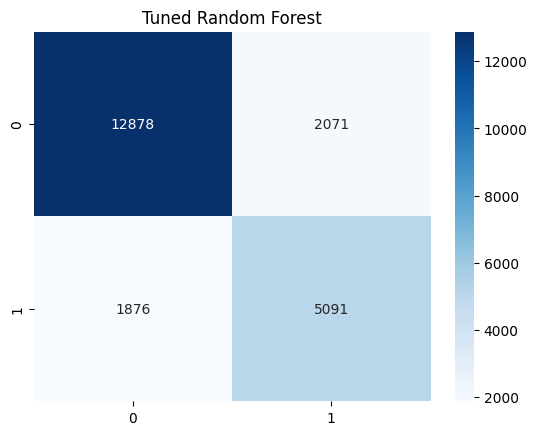

['Tuned Random Forest',
 0.7206454809257555,
 0.8916529155446395,
 0.7108349623010333,
 0.730730587053251]

In [111]:
model("Tuned Random Forest", best_rf_model, X_test, y_test)

In [112]:
joblib.dump(best_rf_model, 'classifier.joblib')

['classifier.joblib']

## Regression Models

### Feature Importance

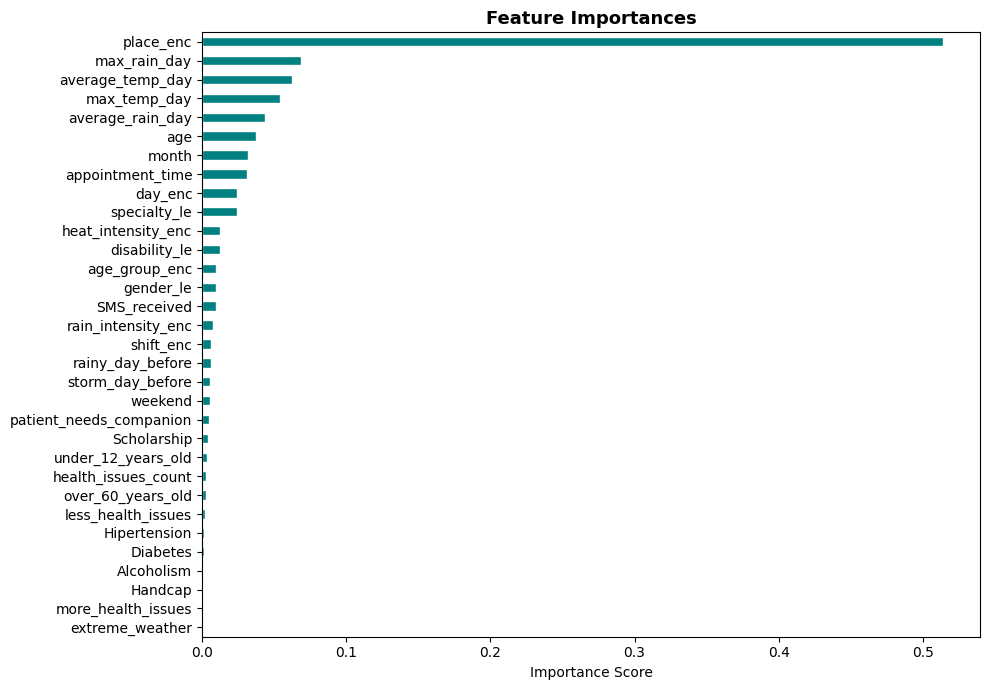

In [113]:
importances = pd.Series(best_rf_model.feature_importances_,index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 7))
importances.sort_values().plot(kind='barh',color='teal',edgecolor='white')
plt.title('Feature Importances',fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### Outliers removal

Outliers should have been removed earlier (while cleaning the database)

Without removing the outliers, the forecasting models will not give us the desired result.

In [335]:
df=pd.read_csv("Clean_total7_enc.csv")

In [336]:
daily_df = df.groupby('appointment_date_continuous').size().reset_index(name='daily_appointments')

In [337]:
daily_df = daily_df.sort_values('appointment_date_continuous')

In [338]:
daily_df["appointment_date_continuous"] = pd.to_datetime(daily_df["appointment_date_continuous"])

In [339]:
daily_df = daily_df[daily_df['daily_appointments'] > 50]

In [340]:
Q1 = daily_df['daily_appointments'].quantile(0.25)
Q3 = daily_df['daily_appointments'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
daily_df = daily_df[daily_df['daily_appointments'] <= upper_bound]

print(f"Cleaned data now ranges from {daily_df.daily_appointments.min()} to {daily_df.daily_appointments.max()}")

Cleaned data now ranges from 51 to 985


In [341]:
daily_df.to_csv('Final_encr.csv', index=False)

### Dataframe

In [342]:
daily = pd.read_csv("Final_encr.csv")

In [343]:
daily['appointment_date_continuous'] = pd.to_datetime(daily['appointment_date_continuous'])

In [344]:
daily['lag_1'] = daily['daily_appointments'].shift(1)
daily['lag_7'] = daily['daily_appointments'].shift(7)
daily['lag_14'] = daily['daily_appointments'].shift(14)

In [345]:
daily['rolling_7'] = daily['daily_appointments'].rolling(7).mean()
daily['rolling_14'] = daily['daily_appointments'].rolling(14).mean()
daily['rolling_std_7'] = daily['daily_appointments'].rolling(7).std()
daily['ema_7'] = daily['daily_appointments'].ewm(span=7).mean()
daily['diff_1'] = daily['daily_appointments'].diff(1)

In [346]:
daily['day_of_week'] = daily['appointment_date_continuous'].dt.dayofweek
daily['month'] = daily['appointment_date_continuous'].dt.month
daily['is_weekend'] = daily['day_of_week'].isin([5, 6]).astype(int)

In [347]:
daily = pd.get_dummies(daily, columns=['day_of_week'], prefix='day')

In [348]:
daily.dropna(inplace=True)

### Train and Test Split

In [349]:
X = daily.drop(columns=['appointment_date_continuous','daily_appointments'])
y = daily['daily_appointments']

In [350]:
split = int(len(daily) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

### Random Forest Regressor

In [351]:
rf_reg = RandomForestRegressor(n_estimators=300,max_depth=10,min_samples_split=5,min_samples_leaf=2,random_state=42)

rf_reg.fit(X_train, y_train)
pred_rf = rf_reg.predict(X_test)

### XGBoost Regressor

In [352]:
xgb_reg = XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5, subsample=0.8, colsample_bytree=0.8, random_state=42)

xgb_reg.fit(X_train, y_train)
pred_xgb = xgb_reg.predict(X_test)

### ARIMA

In [353]:
daily_arima = daily.set_index('appointment_date_continuous')

daily_arima = daily_arima.asfreq('D')
daily_arima['daily_appointments'] = daily_arima['daily_appointments'].interpolate()

y_arima = daily_arima['daily_appointments']

split_arima = int(len(y_arima) * 0.8)
y_train_arima = y_arima.iloc[:split_arima]
y_test_arima = y_arima.iloc[split_arima:]

arima = ARIMA(y_train_arima,order=(5,1,0))
arima_fit = arima.fit()
pred_arima = arima_fit.forecast(steps=len(y_test_arima))

In [354]:
def evaluate(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true,y_pred)
    r2 = r2_score(y_true, y_pred)

    print(name)
    print("MAE  :", round(mae, 3))
    print("MAPE :", round(mape * 100, 2), "%")
    print("R2   :", round(r2, 4))
    print("\n")

In [355]:
evaluate("Random Forest", y_test, pred_rf)
evaluate("XGBoost", y_test, pred_xgb)
evaluate("ARIMA", y_test_arima, pred_arima)

Random Forest
MAE  : 64.323
MAPE : 24.79 %
R2   : 0.8779


XGBoost
MAE  : 48.585
MAPE : 19.15 %
R2   : 0.9188


ARIMA
MAE  : 169.998
MAPE : 82.6 %
R2   : 0.0002




### Saving the best regressor

XGBoost regressor meets our required values ( MAPE <20% and R2 >0.6 )

In [188]:
joblib.dump(xgb_reg,'forecaster.joblib')

['forecaster.joblib']

## EDA

### Forecast vs Actual

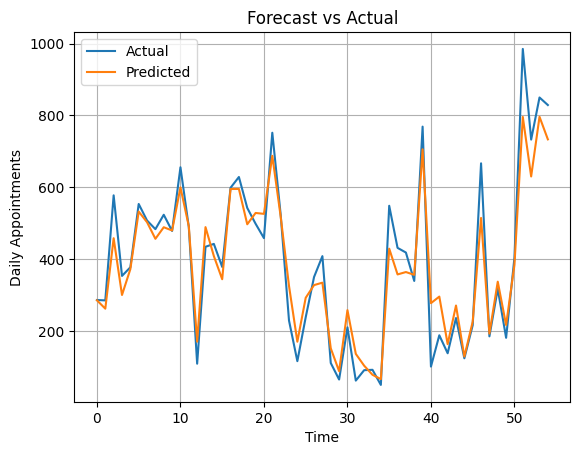

In [357]:
plt.plot(y_test.values,label='Actual')
plt.plot(pred_xgb,label='Predicted')

plt.title('Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Daily Appointments')
plt.legend()
plt.grid(True)
plt.show()

### Residual Plot

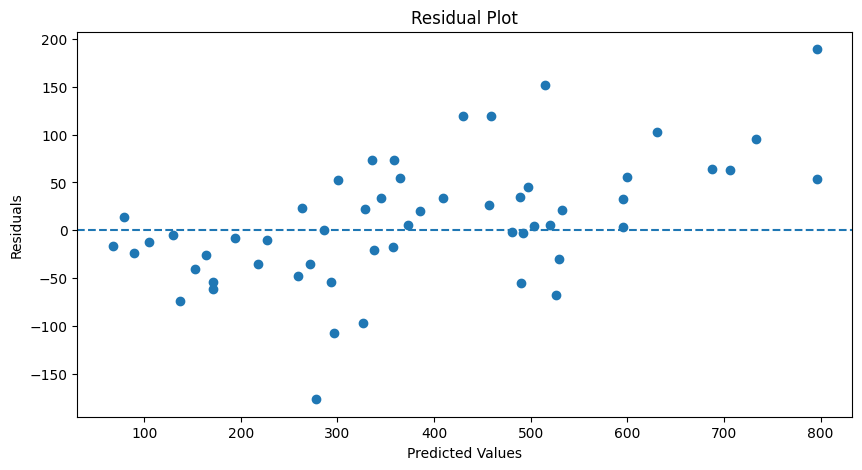

In [358]:
residuals = y_test - pred_xgb

plt.figure(figsize=(10, 5))
plt.scatter(pred_xgb,residuals)
plt.axhline(y=0,linestyle='--')
plt.title('Residual Plot')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

### XGBoost Feature Importance

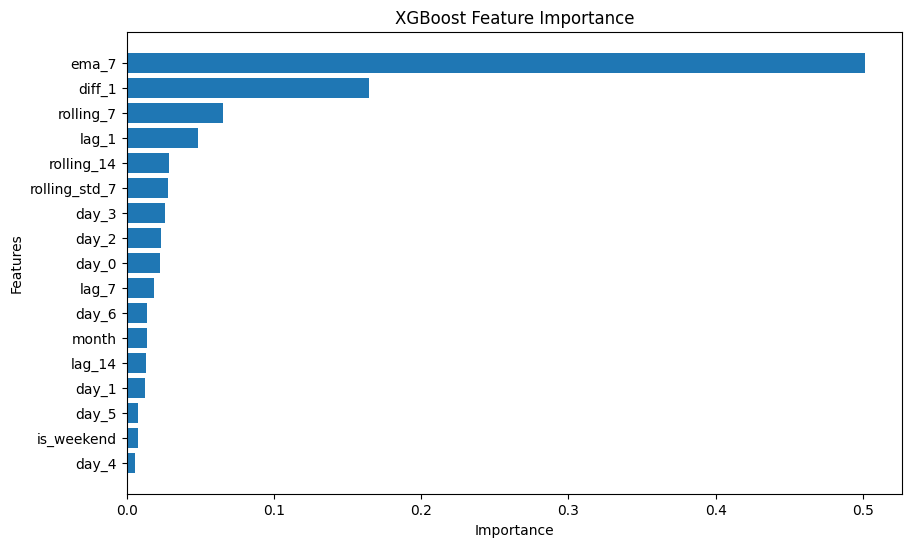

In [356]:
importance_new = pd.DataFrame({'Feature': X_train.columns,'Importance': xgb_reg.feature_importances_})
importance_new = importance_new.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_new['Feature'],importance_new['Importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

In [208]:
df2=pd.read_csv("Clean_total5.csv")

In [214]:
print(df2['no_show'].unique())

['yes' 'no']


In [215]:
df2['no_show'] = df2['no_show'].map({'No': 0,'Yes': 1})

In [218]:
df2['no_show'] = (
    df2['no_show']
    .astype(float)
)

In [219]:
specialty_risk = (

    df2.groupby('specialty')['no_show']

    .mean()

    .sort_values(ascending=False)

)

print(specialty_risk.head(10))

specialty
Assist                 NaN
Enf                    NaN
Occupational Therapy   NaN
Pedagogo               NaN
Physiotherapy          NaN
Psychotherapy          NaN
Sem Especialidade      NaN
Speech Therapy         NaN
Unknown                NaN
Name: no_show, dtype: float64


In [211]:
print(df2.columns)

Index(['specialty', 'appointment_time', 'gender', 'no_show', 'disability',
       'place', 'appointment_shift', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity',
       'appointment_date_continuous', 'Hipertension', 'Diabetes', 'Alcoholism',
       'Handcap', 'Scholarship', 'SMS_received', 'day', 'month', 'weekend',
       'age_group', 'health_issues_count', 'less_health_issues',
       'more_health_issues', 'extreme_weather'],
      dtype='object')


In [212]:
print(df2.dtypes)

specialty                       object
appointment_time                 int64
gender                          object
no_show                         object
disability                      object
place                           object
appointment_shift               object
age                              int64
under_12_years_old               int64
over_60_years_old                int64
patient_needs_companion          int64
average_temp_day               float64
average_rain_day               float64
max_temp_day                   float64
max_rain_day                   float64
rainy_day_before                 int64
storm_day_before                 int64
rain_intensity                  object
heat_intensity                  object
appointment_date_continuous     object
Hipertension                     int64
Diabetes                         int64
Alcoholism                       int64
Handcap                          int64
Scholarship                      int64
SMS_received             

In [135]:
df=pd.read_csv('final_encr.csv')

In [136]:
df['appointment_date_continuous'] = pd.to_datetime(
    df['appointment_date_continuous']
).dt.date

In [137]:
daily = (df.groupby('appointment_date_continuous').size().reset_index(name='daily_appointments'))

In [138]:
print(daily.head())

print(daily['daily_appointments'].describe())

  appointment_date_continuous  daily_appointments
0                  2020-01-29                   1
1                  2020-01-30                   1
2                  2020-01-31                   1
3                  2020-02-01                   1
4                  2020-02-02                   1
count    286.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: daily_appointments, dtype: float64


In [139]:

daily['lag_1'] = (
    daily['daily_appointments']
    .shift(1)
)

daily['lag_7'] = (
    daily['daily_appointments']
    .shift(7)
)

daily['lag_14'] = (
    daily['daily_appointments']
    .shift(14)
)

daily['lag_30'] = (
    daily['daily_appointments']
    .shift(30)
)

In [140]:

daily['rolling_7'] = (
    daily['daily_appointments']
    .rolling(7)
    .mean()
)

daily['rolling_14'] = (
    daily['daily_appointments']
    .rolling(14)
    .mean()
)

daily['rolling_30'] = (
    daily['daily_appointments']
    .rolling(30)
    .mean()
)

In [141]:
daily['day'] = (
    daily['appointment_date_continuous']
    .dt.dayofweek
)

daily['month'] = (
    daily['appointment_date_continuous']
    .dt.month
)

daily['is_weekend'] = (
    daily['day']
    .isin([5, 6])
    .astype(int)
)

daily['week'] = (
    daily['appointment_date_continuous']
    .dt.isocalendar()
    .week
)

AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
daily.dropna(inplace=True)


In [ ]:
daily['appointment_date_continuous'] = pd.to_datetime(
    daily['appointment_date_continuous'],
    errors='coerce'
)

In [ ]:
print(daily.head(20))

print(daily['daily_appointments'].describe())

In [ ]:
X = daily.drop(
    columns=[
        'appointment_date_continuous',
        'daily_appointments'
    ]
)

y = daily['daily_appointments']

In [ ]:
split = int(len(daily) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [ ]:
rf_reg = RandomForestRegressor(
    random_state=42
)

rf_reg.fit(X_train, y_train)

pred_rf = rf_reg.predict(X_test)

In [ ]:
xgb_reg = XGBRegressor(
    random_state=42
)

xgb_reg.fit(X_train, y_train)

pred_xgb = xgb_reg.predict(X_test)

In [ ]:
daily_arima = daily.copy()

daily_arima = daily_arima.set_index(
    'appointment_date_continuous'
)

y_arima = daily_arima['daily_appointments']

split_arima = int(len(y_arima) * 0.8)

y_train_arima = y_arima.iloc[:split_arima]

y_test_arima = y_arima.iloc[split_arima:]

arima = ARIMA(
    y_train_arima,
    order=(5,1,0)
)

arima_fit = arima.fit()

pred_arima = arima_fit.forecast(
    steps=len(y_test_arima)
)

In [ ]:
def forecast(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    )

    r2 = r2_score(y_true, y_pred)

    print("\n", name)

    print("MAE  :", round(mae, 2))

    print("MAPE :", round(mape * 100, 2), "%")

    print("R2   :", round(r2, 4))

In [ ]:

forecast(
    "Random Forest",
    y_test,
    pred_rf
)

forecast(
    "XGBoost",
    y_test,
    pred_xgb
)

forecast(
    "ARIMA",
    y_test_arima,
    pred_arima
)